# 🌲 Deteksi Anomali Ekonomi Makro — Isolation Forest

**Early Warning System Krisis Ekonomi menggunakan Isolation Forest (Machine Learning)**

---

Notebook ini mengimplementasikan pendekatan **Isolation Forest** untuk mendeteksi anomali pada indikator ekonomi makro sebagai sistem peringatan dini (*Early Warning System*) krisis ekonomi.

**Metodologi:**
- Algoritma: Isolation Forest (Ensemble of Isolation Trees)
- Hyperparameter Tuning: Grid search pada `contamination` dan `n_estimators`
- Threshold: Decision function score (semakin negatif = semakin anomali)
- Evaluasi: Precision, Recall, F1-Score, ROC-AUC, Precision-Recall Curve
- Interpretasi: Feature importance berbasis *anomaly score differential*
- Visualisasi: PCA, t-SNE, timeline temporal

**Dataset:** 14 indikator makroekonomi, 49 negara, periode 1990–2024 (World Bank Open Data)  
**Disusun oleh:** Raya

## 1. Import Library

In [1]:
# ── Import Library ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Konfigurasi visualisasi
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 2. Load & Eksplorasi Data

In [2]:
# ── Load dataset ────────────────────────────────────────────────────────
df = pd.read_csv('../data_cleaned.csv')

print(f"Shape dataset: {df.shape}")
print(f"Jumlah negara: {df['economy'].nunique()}")
print(f"Rentang tahun: {df['year'].min()} – {df['year'].max()}")
print(f"\nDistribusi crisis_label:")
print(df['crisis_label'].value_counts())
print(f"\nPersentase krisis: {df['crisis_label'].mean()*100:.2f}%")

df.head()

Shape dataset: (1714, 17)
Jumlah negara: 49
Rentang tahun: 1990 – 2024

Distribusi crisis_label:
crisis_label
0    1385
1     329
Name: count, dtype: int64

Persentase krisis: 19.19%


,economy,year,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP,crisis_label
0,ARE,1990,2.690913,2.607447,-0.035597,-0.349079,-1.105892,2.12939,0.234573,-0.486899,0.326385,0.123081,1.10385,-0.224663,-1.589531,-0.270213,0
1,ARE,1991,-0.638363,-1.838101,-0.035597,-0.347005,-1.105892,2.12939,0.234573,-0.448764,0.326385,0.123081,1.10385,-0.224663,-1.601884,-0.270213,0
2,ARE,1992,0.032110,-1.108947,-0.035597,-0.346099,-1.087378,2.12939,0.234573,-0.422930,0.326385,0.123081,1.10385,-0.224663,-1.573871,-0.270213,0
3,ARE,1993,-0.530135,-1.574741,-0.035597,-0.344897,-1.047336,2.12939,0.234573,-0.356948,0.326385,0.123081,1.10385,-0.224663,-1.528502,-0.270213,0
4,ARE,1994,0.990307,-0.018863,-0.035597,-0.343393,-1.061760,2.12939,0.234573,-0.441240,0.326385,0.123081,1.10385,-0.224663,-1.747591,-0.270213,0


In [3]:
# ── Daftar 14 fitur indikator makroekonomi ──────────────────────────────
FEATURE_COLS = [
    'GDP_Growth', 'GDP_PerCapita_Growth', 'Inflation_CPI',
    'Total_Reserves', 'Unemployment', 'Current_Account_GDP',
    'Trade_GDP', 'FDI_Inflows_GDP', 'Exports_GDP', 'Imports_GDP',
    'Gross_Savings_GDP', 'Exchange_Rate', 'Manufacturing_Value',
    'Investment_GDP'
]

# Label deskriptif untuk visualisasi
FEATURE_LABELS = {
    'GDP_Growth': 'Pertumbuhan PDB (%)',
    'GDP_PerCapita_Growth': 'PDB per Kapita Growth (%)',
    'Inflation_CPI': 'Inflasi CPI (%)',
    'Total_Reserves': 'Cadangan Devisa',
    'Unemployment': 'Pengangguran (%)',
    'Current_Account_GDP': 'Neraca Berjalan/PDB (%)',
    'Trade_GDP': 'Perdagangan/PDB (%)',
    'FDI_Inflows_GDP': 'FDI Masuk/PDB (%)',
    'Exports_GDP': 'Ekspor/PDB (%)',
    'Imports_GDP': 'Impor/PDB (%)',
    'Gross_Savings_GDP': 'Tabungan Bruto/PDB (%)',
    'Exchange_Rate': 'Nilai Tukar (LCU/USD)',
    'Manufacturing_Value': 'Manufaktur/PDB (%)',
    'Investment_GDP': 'Investasi/PDB (%)'
}

print(f"Jumlah fitur: {len(FEATURE_COLS)}")
print(f"Missing values per fitur:")
print(df[FEATURE_COLS].isnull().sum())
print(f"\nStatistik deskriptif (data sudah ter-standardisasi z-score):")
df[FEATURE_COLS].describe().round(3)

Jumlah fitur: 14
Missing values per fitur:
GDP_Growth              0
GDP_PerCapita_Growth    0
Inflation_CPI           0
Total_Reserves          0
Unemployment            0
Current_Account_GDP     0
Trade_GDP               0
FDI_Inflows_GDP         0
Exports_GDP             0
Imports_GDP             0
Gross_Savings_GDP       0
Exchange_Rate           0
Manufacturing_Value     0
Investment_GDP          0
dtype: int64

Statistik deskriptif (data sudah ter-standardisasi z-score):


,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP
count,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000
mean,-0.002,-0.001,-0.035,-0.003,-0.004,0.001,-0.003,-0.005,-0.003,-0.002,-0.000,-0.002,-0.001,-0.002
std,0.977,0.982,0.268,0.969,0.982,0.980,0.985,0.852,0.985,0.985,0.996,0.983,0.996,0.989
min,-3.815,-3.711,-0.100,-0.360,-1.329,-2.310,-1.058,-3.011,-1.016,-1.120,-2.163,-0.226,-1.915,-1.987
25%,-0.477,-0.429,-0.084,-0.322,-0.654,-0.615,-0.578,-0.342,-0.581,-0.591,-0.729,-0.226,-0.749,-0.635
50%,0.005,0.012,-0.077,-0.259,-0.261,-0.178,-0.303,-0.185,-0.310,-0.292,-0.157,-0.224,-0.090,-0.150
75%,0.561,0.580,-0.058,-0.095,0.360,0.368,0.186,0.046,0.200,0.212,0.612,-0.205,0.559,0.425
max,2.691,2.758,3.206,8.628,4.312,3.879,5.122,5.938,5.054,5.143,3.072,7.330,2.674,3.378


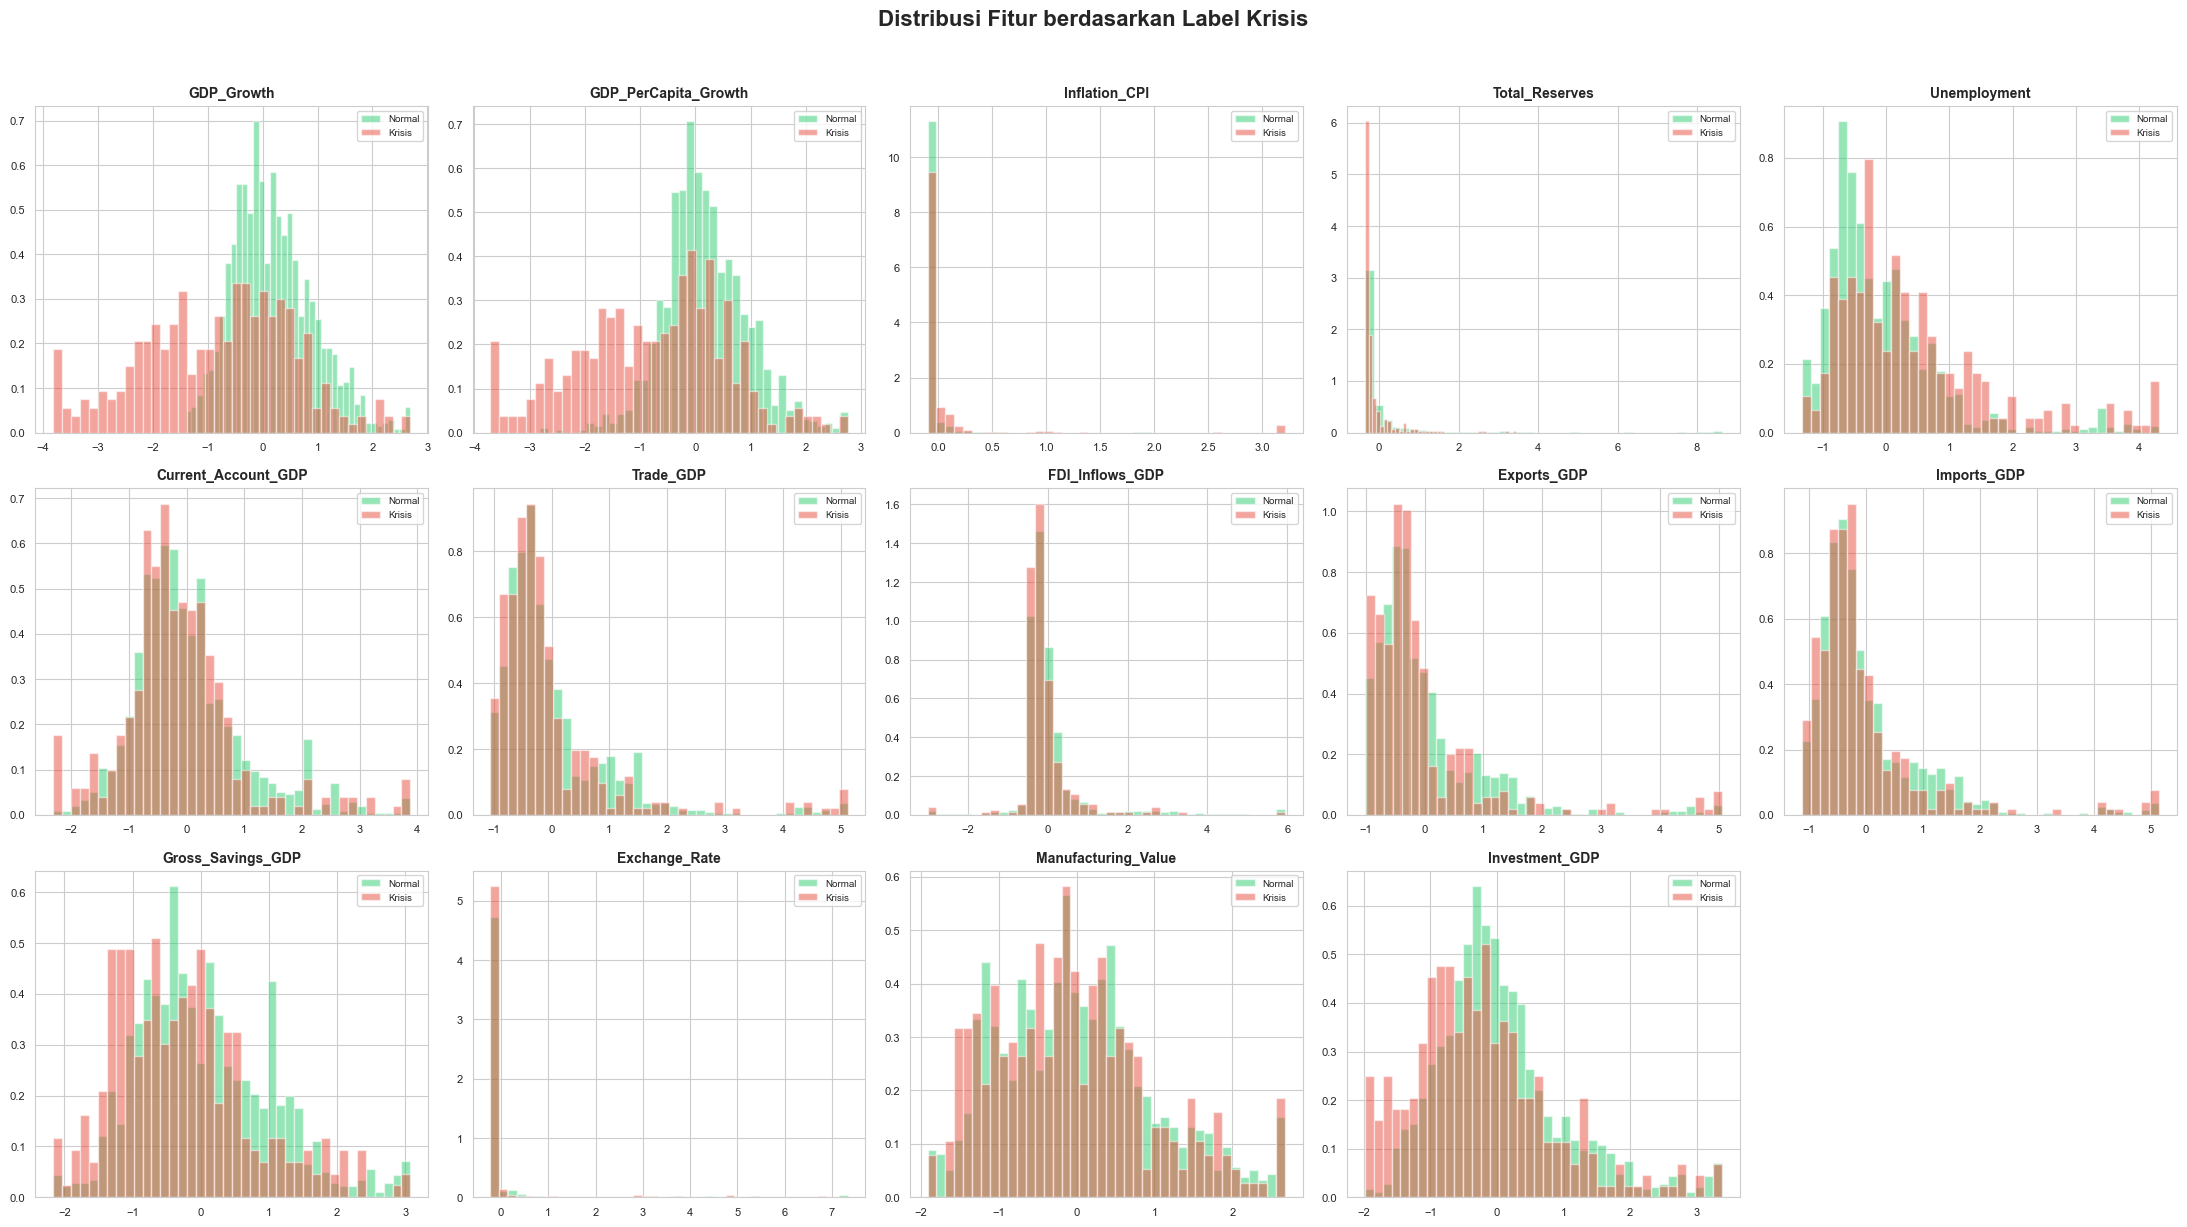

In [4]:
# ── Visualisasi distribusi fitur ────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()
for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.hist(df[df['crisis_label']==0][col], bins=40, alpha=0.5, color='#2ecc71', label='Normal', density=True)
    ax.hist(df[df['crisis_label']==1][col], bins=40, alpha=0.5, color='#e74c3c', label='Krisis', density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)
# Hapus subplot terakhir yang tidak dipakai
axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur berdasarkan Label Krisis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

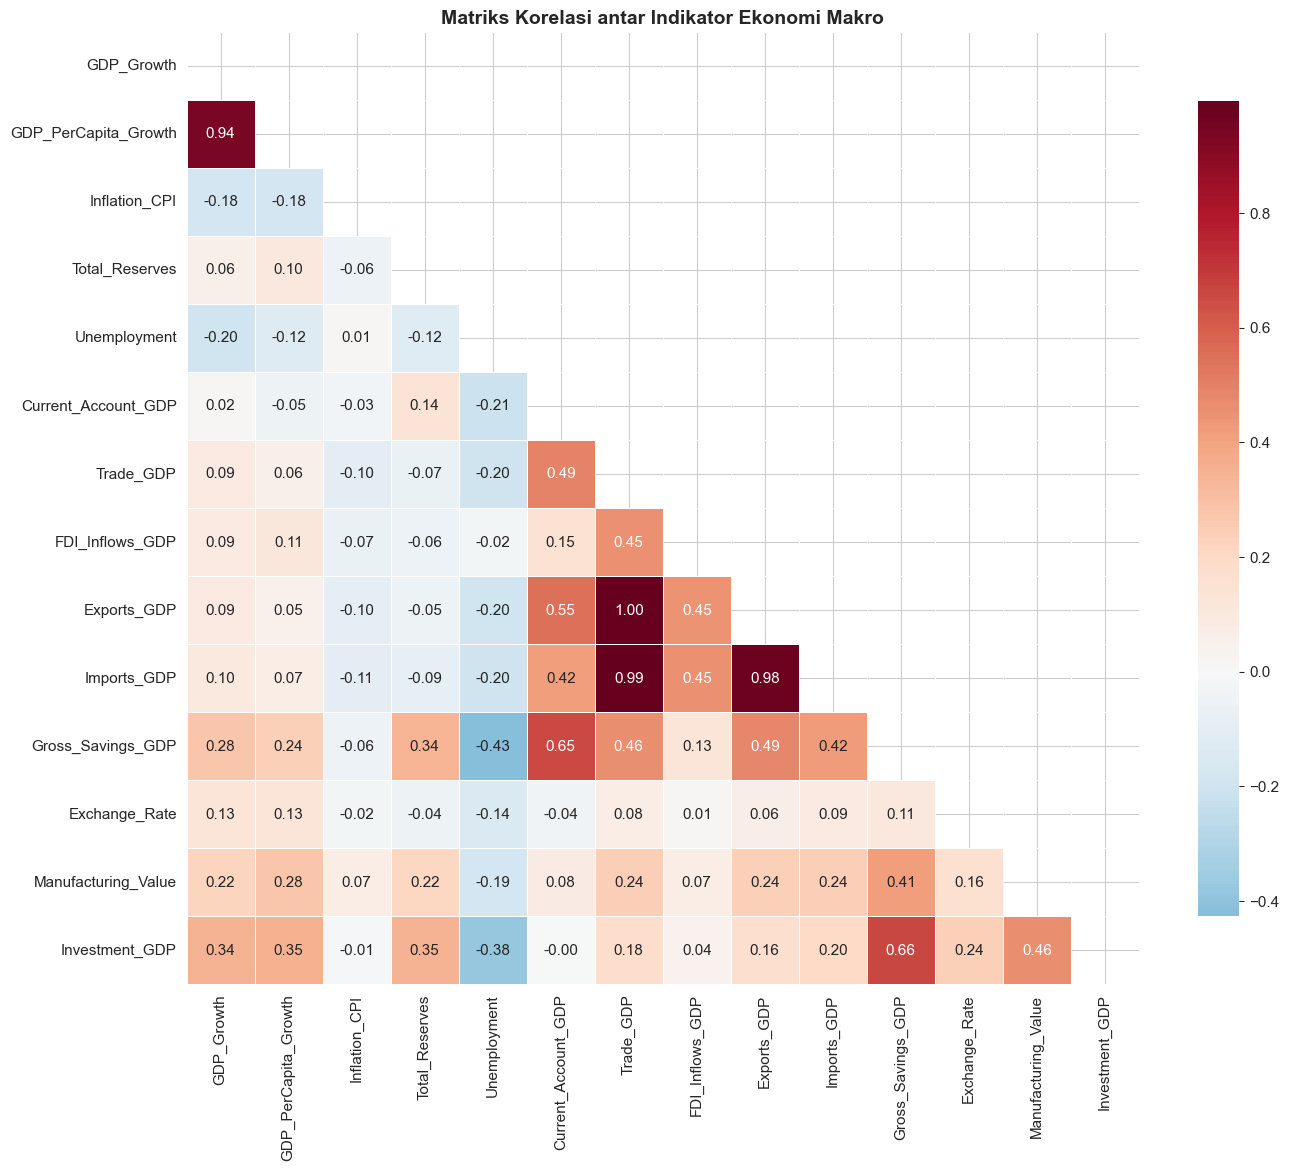

In [5]:
# ── Correlation Heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriks Korelasi antar Indikator Ekonomi Makro', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Persiapan Data untuk Isolation Forest

In [6]:
# ── Siapkan matriks fitur ───────────────────────────────────────────────
# Kolom yang TIDAK digunakan untuk training:
#   - 'economy' dan 'year' adalah identitas
#   - 'crisis_label' adalah ground truth (hanya untuk evaluasi)
X = df[FEATURE_COLS].copy()
y_true = df['crisis_label'].copy()
crisis_ratio = y_true.mean()

print(f"Dimensi fitur X: {X.shape}")
print(f"Distribusi crisis_label:")
print(y_true.value_counts())
print(f"\nProporsi krisis: {crisis_ratio:.4f} ({crisis_ratio*100:.2f}%)")
print(f"Proporsi normal: {1-crisis_ratio:.4f} ({(1-crisis_ratio)*100:.2f}%)")
print(f"\nTotal missing values: {X.isnull().sum().sum()}")

Dimensi fitur X: (1714, 14)
Distribusi crisis_label:
crisis_label
0    1385
1     329
Name: count, dtype: int64

Proporsi krisis: 0.1919 (19.19%)
Proporsi normal: 0.8081 (80.81%)

Total missing values: 0


In [7]:
# ── Split data: Train (80%) dan Test (20%) ──────────────────────────────
# Meskipun Isolation Forest bersifat unsupervised, kita tetap split
# untuk evaluasi yang lebih fair (out-of-sample evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_true, test_size=0.2, random_state=RANDOM_STATE, stratify=y_true
)

print(f"Train set: {X_train.shape[0]} sampel")
print(f"  - Normal: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"  - Krisis: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nTest set: {X_test.shape[0]} sampel")
print(f"  - Normal: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"  - Krisis: {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")

Train set: 1371 sampel
  - Normal: 1108 (80.8%)
  - Krisis: 263 (19.2%)

Test set: 343 sampel
  - Normal: 277 (80.8%)
  - Krisis: 66 (19.2%)


## 4. Konsep dan Arsitektur Isolation Forest

### Prinsip Kerja:
Isolation Forest mengisolasi anomali melalui **partisi acak** pada pohon biner:
1. Pilih fitur secara acak
2. Pilih nilai split acak antara min dan max fitur tersebut
3. Ulangi hingga setiap observasi terisolasi

**Anomali** memiliki **path length pendek** (terisolasi cepat).
**Normal** memiliki **path length panjang** (butuh banyak split).

### Hyperparameter Utama:

| Hyperparameter | Deskripsi | Rentang yang Dieksplorasi |
|---|---|---|
| `n_estimators` | Jumlah pohon isolasi | 50, 100, 200, 300, 500 |
| `contamination` | Proporsi estimasi anomali | auto, 0.10, 0.15, ~0.19 |
| `max_samples` | Sampel per pohon | auto (min(256, n)) |
| `max_features` | Fitur per pohon | 1.0 (semua) |
| `random_state` | Seed | 42 |

## 5. Training Isolation Forest — Grid Search

In [8]:
# ── Grid Search: contamination x n_estimators ───────────────────────────
contamination_values = {
    'auto': 'auto',
    '0.10': 0.10,
    '0.15': 0.15,
    f'{crisis_ratio:.4f} (rasio krisis)': round(crisis_ratio, 4)
}

n_estimators_list = [50, 100, 200, 300, 500]

# Dictionary untuk menyimpan semua hasil
all_results = {}

# Training dengan kombinasi hyperparameter
for contam_name, contam_val in contamination_values.items():
    for n_est in n_estimators_list:
        key = f"contam={contam_name}, n_est={n_est}"
        
        iso_forest = IsolationForest(
            n_estimators=n_est,
            contamination=contam_val,
            max_samples='auto',
            max_features=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        
        # Fit pada training set
        iso_forest.fit(X_train)
        
        # Predict pada FULL dataset (train + test)
        y_pred_raw = iso_forest.predict(X)
        anomaly_scores = iso_forest.decision_function(X)
        
        # Konversi: IF output -1=anomali,1=normal -> crisis_label 1=krisis,0=normal
        y_pred_aligned = np.where(y_pred_raw == -1, 1, 0)
        anomaly_scores_negated = -anomaly_scores  # Semakin tinggi = semakin anomali
        
        # Hitung metrik
        f1 = f1_score(y_true, y_pred_aligned)
        auc = roc_auc_score(y_true, anomaly_scores_negated)
        prec = precision_score(y_true, y_pred_aligned, zero_division=0)
        rec = recall_score(y_true, y_pred_aligned)
        ap = average_precision_score(y_true, anomaly_scores_negated)
        
        all_results[key] = {
            'model': iso_forest,
            'contamination': contam_name,
            'n_estimators': n_est,
            'y_pred_aligned': y_pred_aligned,
            'anomaly_scores': anomaly_scores,
            'anomaly_scores_negated': anomaly_scores_negated,
            'f1': f1,
            'auc': auc,
            'precision': prec,
            'recall': rec,
            'avg_precision': ap
        }

print(f"Total model yang dilatih: {len(all_results)}")
print("Grid search selesai!")

Total model yang dilatih: 20
Grid search selesai!


In [9]:
# ── Tabel Ringkasan Grid Search ─────────────────────────────────────────
grid_data = []
for key, res in all_results.items():
    grid_data.append({
        'Contamination': res['contamination'],
        'n_estimators': res['n_estimators'],
        'Precision': round(res['precision'], 4),
        'Recall': round(res['recall'], 4),
        'F1-Score': round(res['f1'], 4),
        'ROC-AUC': round(res['auc'], 4),
        'Avg Precision': round(res['avg_precision'], 4)
    })

grid_df = pd.DataFrame(grid_data)
print("\nHasil Grid Search Lengkap:")
display(grid_df.sort_values('F1-Score', ascending=False).head(10))

# Identifikasi model terbaik
best_idx = grid_df['F1-Score'].idxmax()
best_key = list(all_results.keys())[best_idx]
best_result = all_results[best_key]
print(f"\n>> Model terbaik: {best_key}")
print(f"   F1-Score = {best_result['f1']:.4f}")
print(f"   ROC-AUC  = {best_result['auc']:.4f}")


Hasil Grid Search Lengkap:


,Contamination,n_estimators,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
17,0.1919 (rasio krisis),200,0.3444,0.3465,0.3455,0.6551,0.2966
19,0.1919 (rasio krisis),500,0.3403,0.3465,0.3434,0.6541,0.2928
18,0.1919 (rasio krisis),300,0.3414,0.3435,0.3424,0.6566,0.2973
15,0.1919 (rasio krisis),50,0.3394,0.3404,0.3399,0.6489,0.2880
16,0.1919 (rasio krisis),100,0.3323,0.3343,0.3333,0.6519,0.2962
10,0.15,50,0.3640,0.2888,0.3220,0.6489,0.2880
12,0.15,200,0.3588,0.2857,0.3181,0.6551,0.2966
11,0.15,100,0.3563,0.2827,0.3153,0.6519,0.2962
14,0.15,500,0.3473,0.2766,0.3080,0.6541,0.2928
13,0.15,300,0.3460,0.2766,0.3074,0.6566,0.2973



>> Model terbaik: contam=0.1919 (rasio krisis), n_est=200
   F1-Score = 0.3455
   ROC-AUC  = 0.6551


## 6. Pengaruh n_estimators terhadap Performa

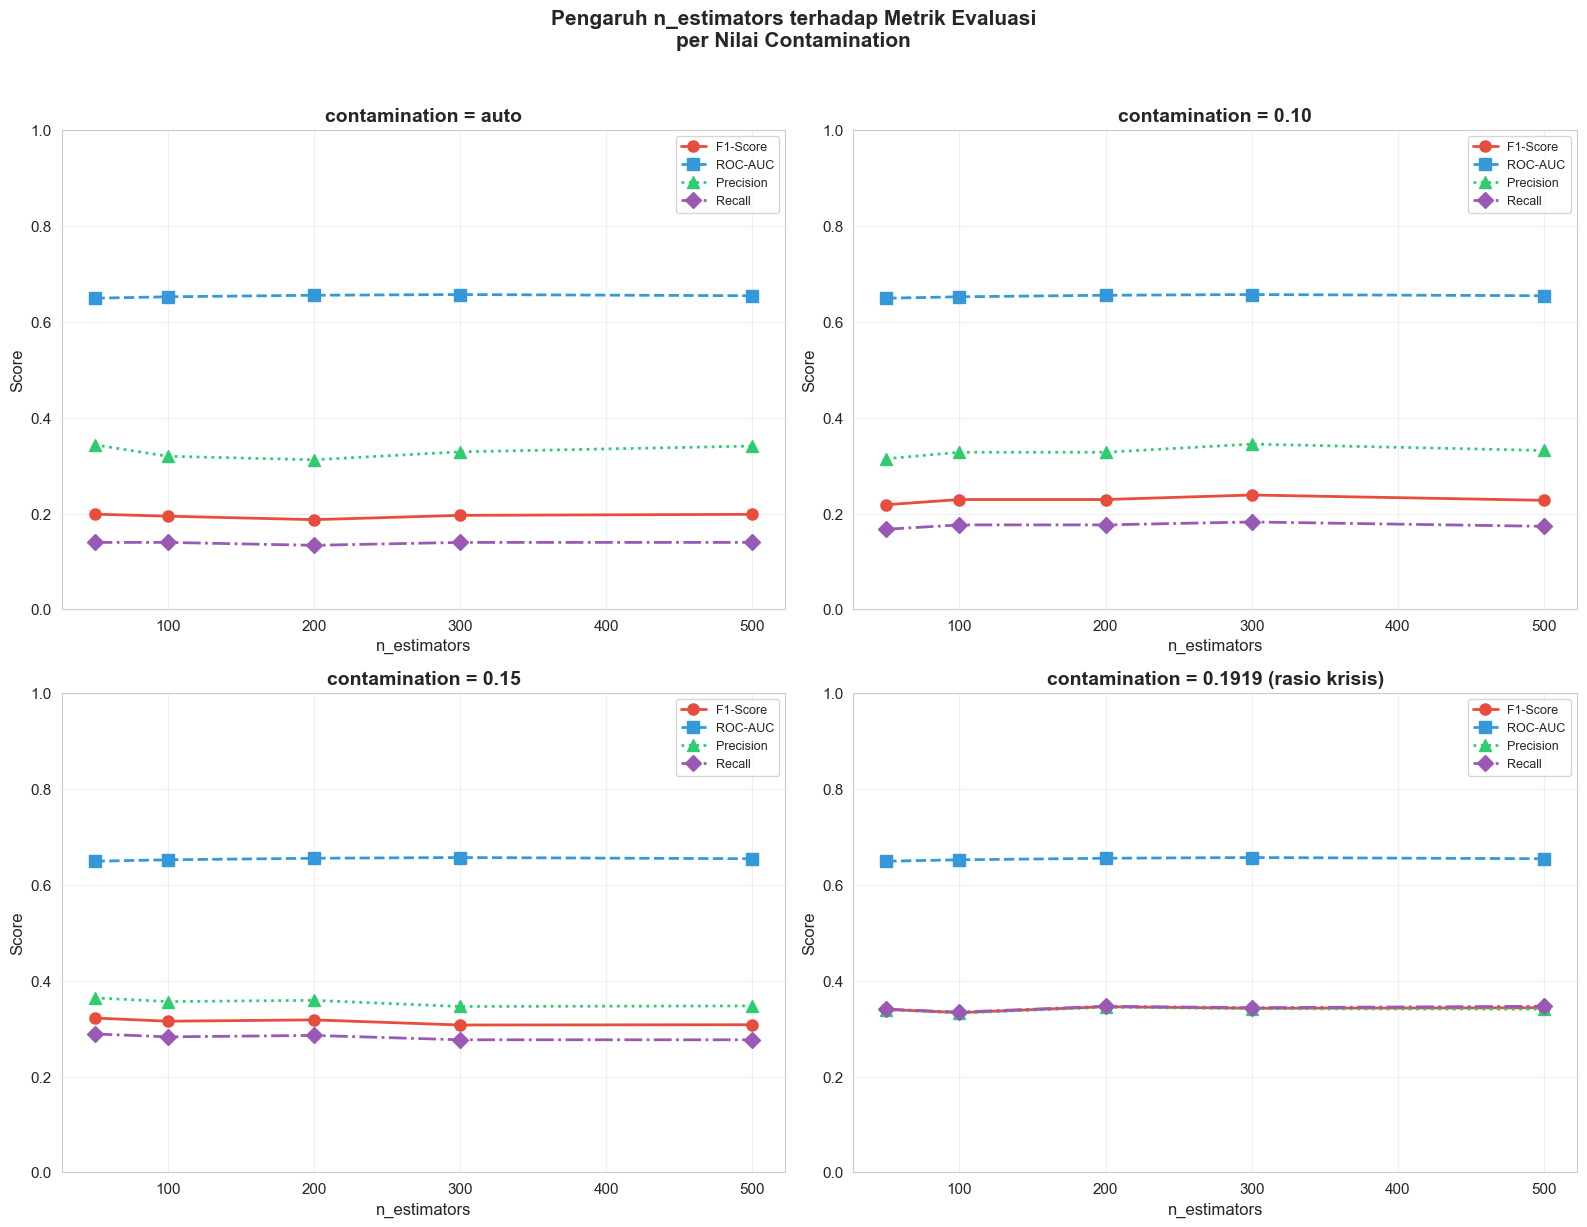

In [10]:
# ── Visualisasi pengaruh n_estimators ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (contam_name, contam_val) in enumerate(contamination_values.items()):
    ax = axes.flatten()[idx]
    subset = grid_df[grid_df['Contamination'] == contam_name]
    
    ax.plot(subset['n_estimators'], subset['F1-Score'], 'o-', 
            color='#e74c3c', lw=2, markersize=8, label='F1-Score')
    ax.plot(subset['n_estimators'], subset['ROC-AUC'], 's--', 
            color='#3498db', lw=2, markersize=8, label='ROC-AUC')
    ax.plot(subset['n_estimators'], subset['Precision'], '^:', 
            color='#2ecc71', lw=2, markersize=8, label='Precision')
    ax.plot(subset['n_estimators'], subset['Recall'], 'D-.', 
            color='#9b59b6', lw=2, markersize=8, label='Recall')
    
    ax.set_title(f'contamination = {contam_name}', fontweight='bold')
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle('Pengaruh n_estimators terhadap Metrik Evaluasi\nper Nilai Contamination',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7. Evaluasi Model Terbaik

In [11]:
# ── Classification Report ───────────────────────────────────────────────
print(f"Model Terbaik: {best_key}")
print("="*60)
print(classification_report(
    y_true,
    best_result['y_pred_aligned'],
    target_names=['Normal (0)', 'Krisis (1)'],
    digits=4
))

Model Terbaik: contam=0.1919 (rasio krisis), n_est=200
              precision    recall  f1-score   support

  Normal (0)     0.8445    0.8433    0.8439      1385
  Krisis (1)     0.3444    0.3465    0.3455       329

    accuracy                         0.7480      1714
   macro avg     0.5945    0.5949    0.5947      1714
weighted avg     0.7485    0.7480    0.7482      1714



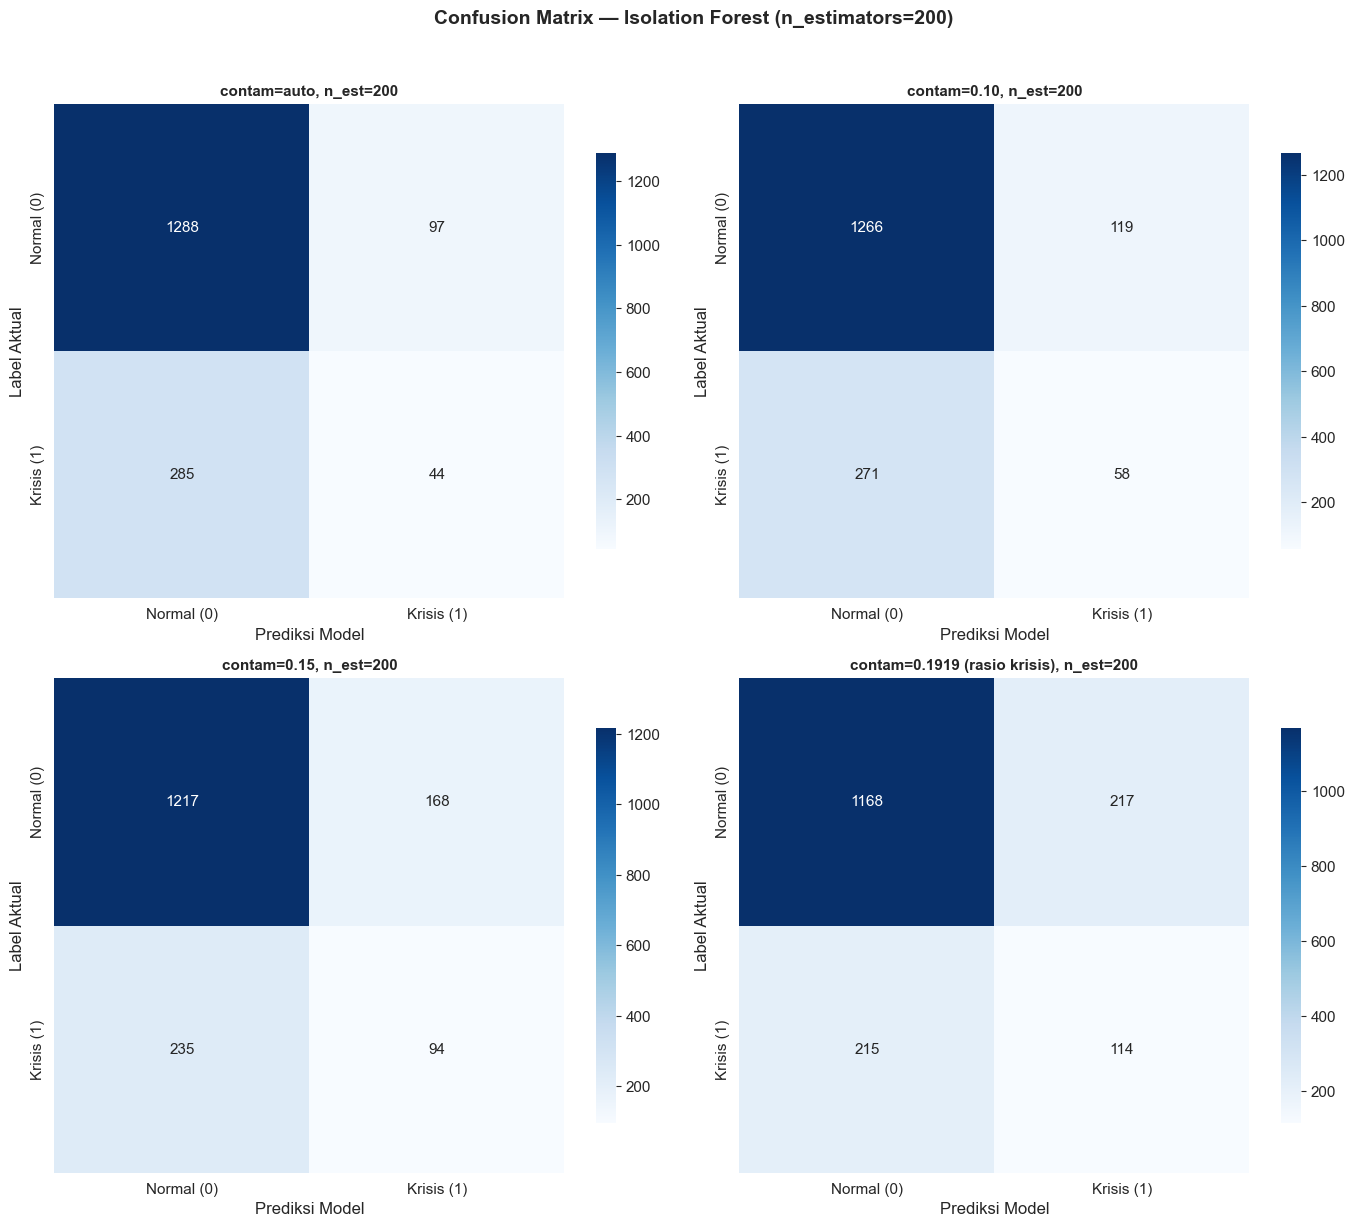

In [12]:
# ── Confusion Matrix ────────────────────────────────────────────────────
# Pilih 4 model representatif (1 per contamination, n_est=200)
representative_keys = [
    k for k in all_results.keys() if 'n_est=200' in k
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, key in enumerate(representative_keys):
    res = all_results[key]
    cm = confusion_matrix(y_true, res['y_pred_aligned'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal (0)', 'Krisis (1)'],
                yticklabels=['Normal (0)', 'Krisis (1)'],
                ax=axes.flatten()[idx], cbar_kws={'shrink': 0.8})
    axes.flatten()[idx].set_title(
        f'contam={res["contamination"]}, n_est={res["n_estimators"]}',
        fontweight='bold', fontsize=11
    )
    axes.flatten()[idx].set_ylabel('Label Aktual')
    axes.flatten()[idx].set_xlabel('Prediksi Model')

plt.suptitle('Confusion Matrix — Isolation Forest (n_estimators=200)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

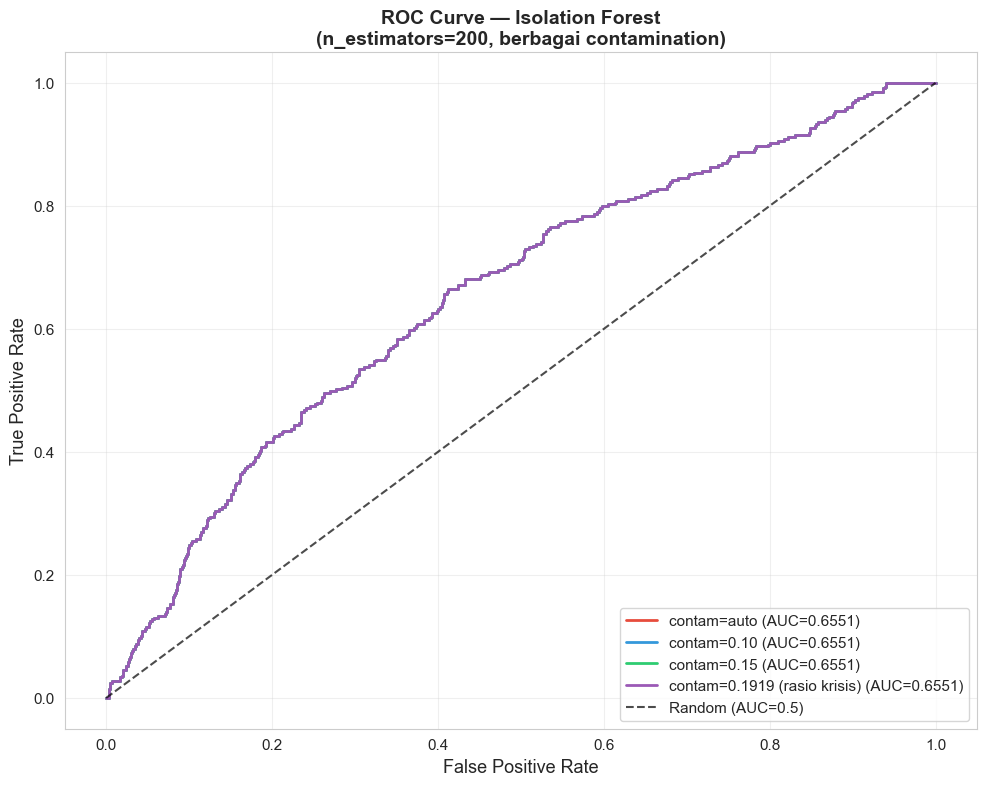

In [13]:
# ── ROC Curve ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for idx, key in enumerate(representative_keys):
    res = all_results[key]
    fpr, tpr, _ = roc_curve(y_true, res['anomaly_scores_negated'])
    auc_val = roc_auc_score(y_true, res['anomaly_scores_negated'])
    ax.plot(fpr, tpr, color=colors[idx], lw=2,
            label=f'contam={res["contamination"]} (AUC={auc_val:.4f})')

ax.plot([0,1], [0,1], 'k--', lw=1.5, alpha=0.7, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve — Isolation Forest\n(n_estimators=200, berbagai contamination)',
             fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

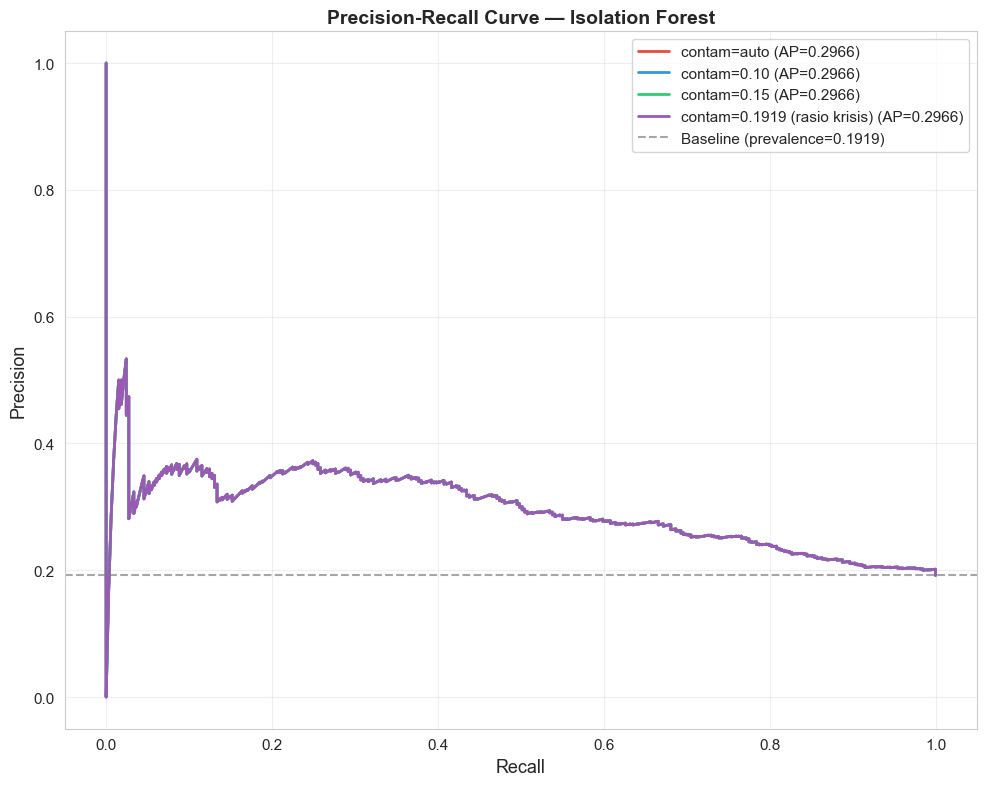

In [14]:
# ── Precision-Recall Curve ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

for idx, key in enumerate(representative_keys):
    res = all_results[key]
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, res['anomaly_scores_negated'])
    ap_ = average_precision_score(y_true, res['anomaly_scores_negated'])
    ax.plot(recall_vals, precision_vals, color=colors[idx], lw=2,
            label=f'contam={res["contamination"]} (AP={ap_:.4f})')

ax.axhline(y=crisis_ratio, color='gray', linestyle='--', lw=1.5, alpha=0.7,
           label=f'Baseline (prevalence={crisis_ratio:.4f})')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Isolation Forest',
             fontweight='bold', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Analisis Anomaly Score

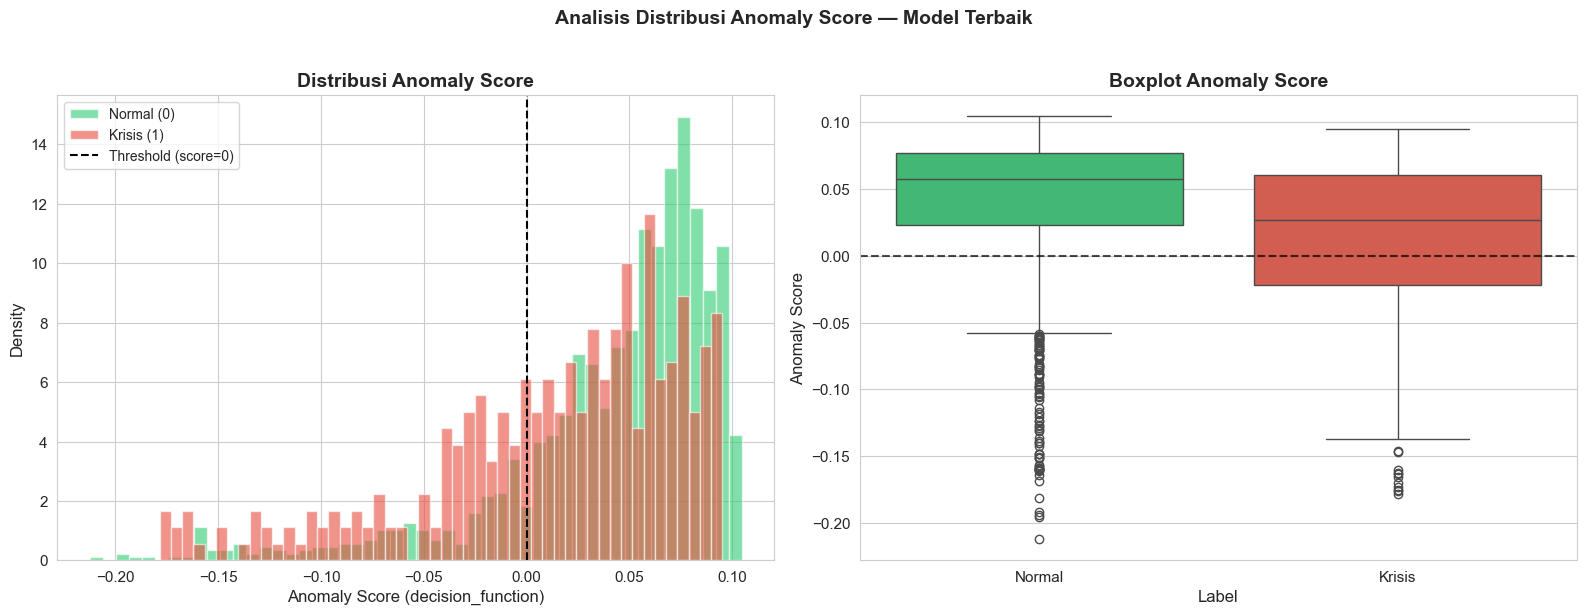

In [15]:
# ── Distribusi Anomaly Score ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scores = best_result['anomaly_scores']

# Histogram
ax1 = axes[0]
ax1.hist(scores[y_true == 0], bins=50, alpha=0.6, color='#2ecc71', label='Normal (0)', density=True)
ax1.hist(scores[y_true == 1], bins=50, alpha=0.6, color='#e74c3c', label='Krisis (1)', density=True)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Threshold (score=0)')
ax1.set_xlabel('Anomaly Score (decision_function)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribusi Anomaly Score', fontweight='bold')
ax1.legend(fontsize=10)

# Boxplot
ax2 = axes[1]
score_df = pd.DataFrame({'Anomaly Score': scores, 'Label': y_true.map({0: 'Normal', 1: 'Krisis'})})
sns.boxplot(data=score_df, x='Label', y='Anomaly Score', palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_title('Boxplot Anomaly Score', fontweight='bold')

plt.suptitle('Analisis Distribusi Anomaly Score — Model Terbaik', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Reduksi Dimensi & Visualisasi

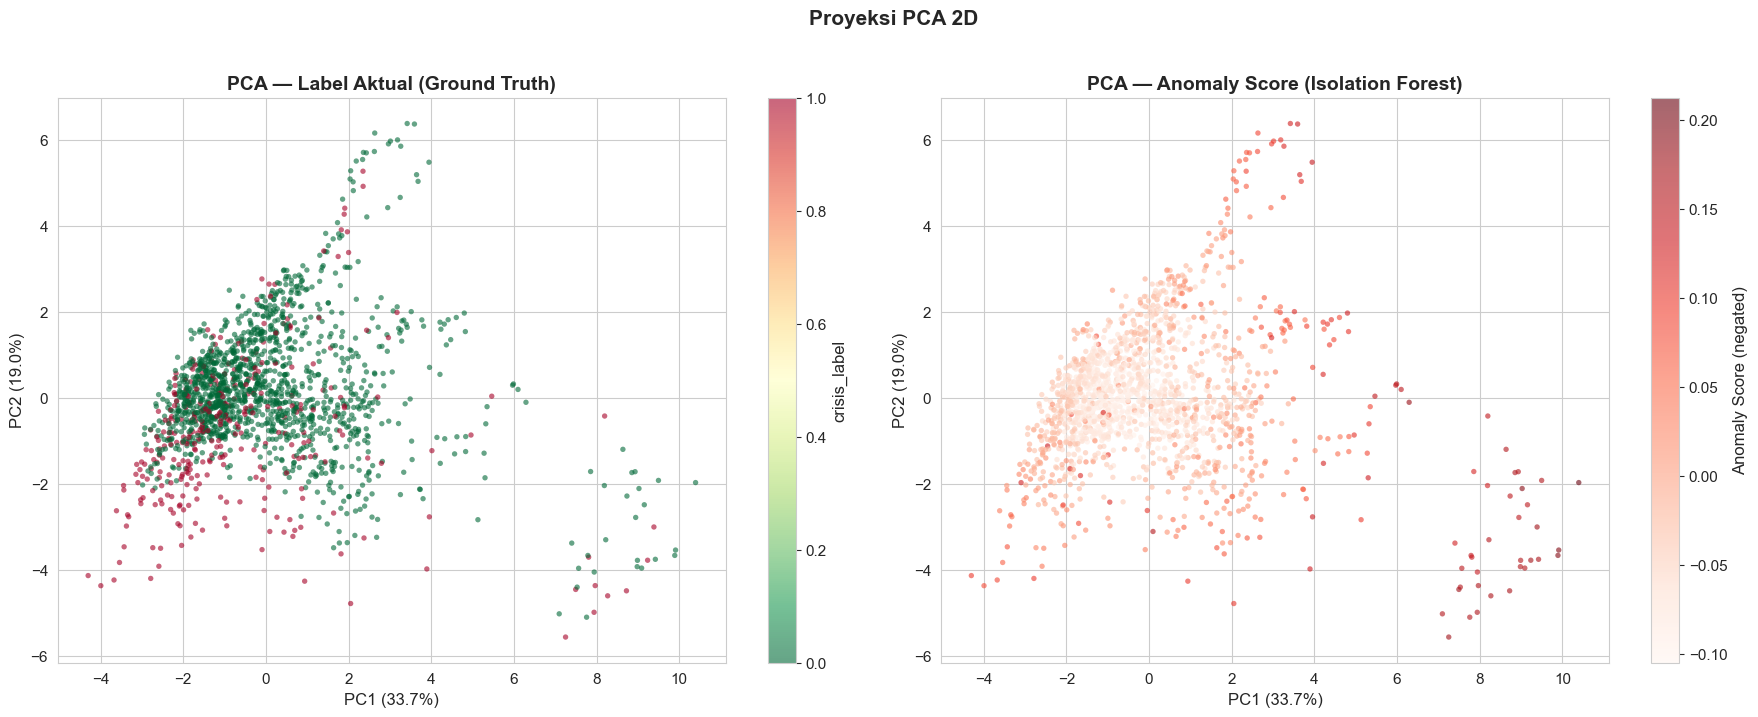

In [16]:
# ── PCA → 2D Projection ─────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Label aktual (crisis_label)
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='RdYlGn_r',
                     alpha=0.6, s=15, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='crisis_label')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Label Aktual (Ground Truth)', fontweight='bold')

# Plot 2: Anomaly score dari model terbaik
ax = axes[1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=best_result['anomaly_scores_negated'],
                     cmap='Reds', alpha=0.6, s=15, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Anomaly Score (negated)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Anomaly Score (Isolation Forest)', fontweight='bold')

plt.suptitle('Proyeksi PCA 2D', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

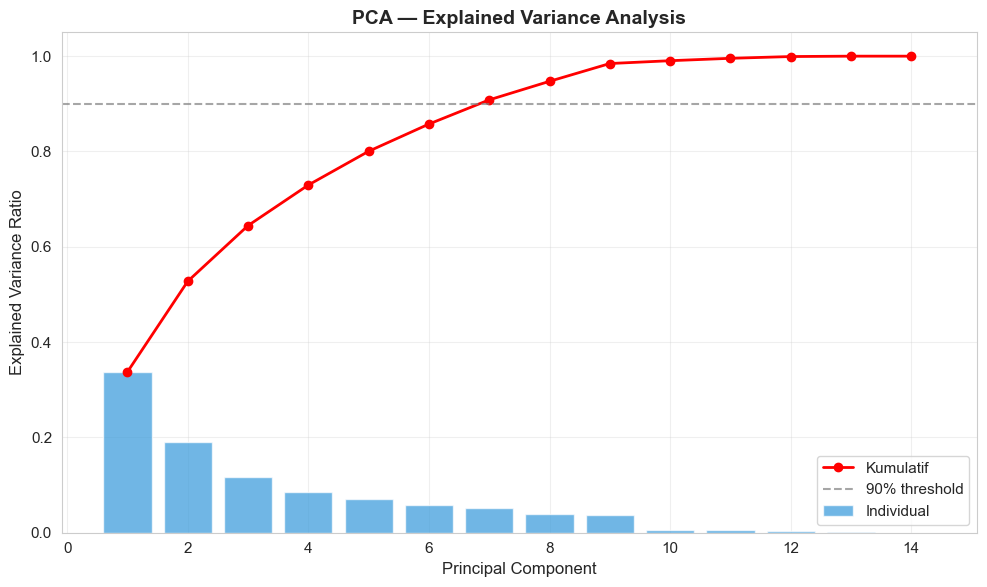

Jumlah komponen untuk 90% variance: 7


In [17]:
# ── PCA: Explained Variance Analysis ────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

fig, ax = plt.subplots(figsize=(10, 6))
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
ax.bar(range(1, len(cumulative_var)+1), pca_full.explained_variance_ratio_, alpha=0.7, color='#3498db', label='Individual')
ax.plot(range(1, len(cumulative_var)+1), cumulative_var, 'ro-', lw=2, label='Kumulatif')
ax.axhline(y=0.90, color='gray', linestyle='--', alpha=0.7, label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance Analysis', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Jumlah komponen untuk 90% variance: {n_90}")

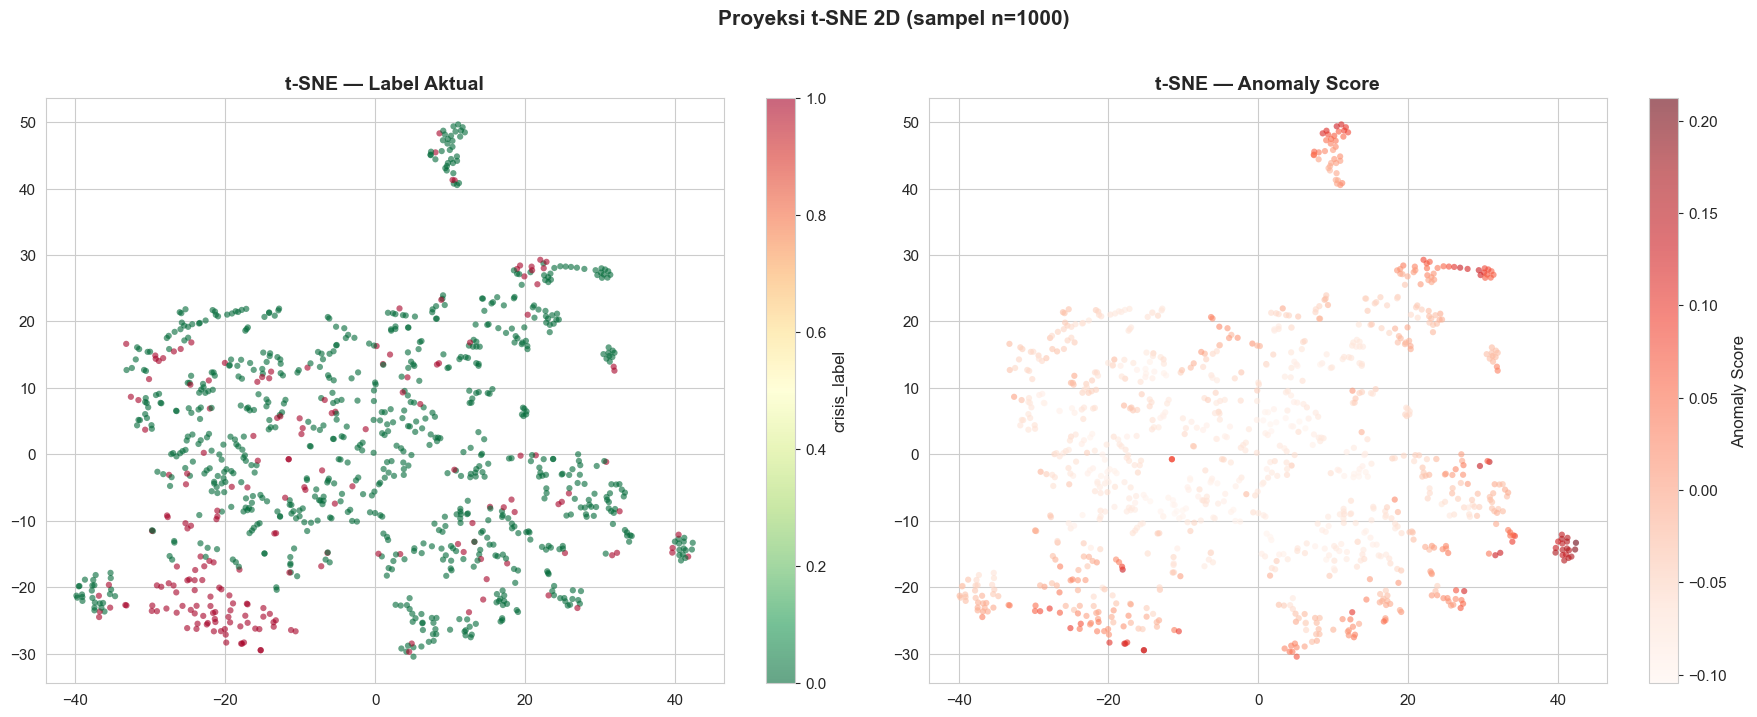

In [18]:
# ── t-SNE → 2D Projection ───────────────────────────────────────────────
# Menggunakan subset untuk kecepatan
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X), size=min(1000, len(X)), replace=False)
X_sample = X.iloc[sample_idx]
y_sample = y_true.iloc[sample_idx]
scores_sample = best_result['anomaly_scores_negated'][sample_idx]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Ground Truth
ax = axes[0]
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='RdYlGn_r',
                     alpha=0.6, s=20, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='crisis_label')
ax.set_title('t-SNE — Label Aktual', fontweight='bold')

# Plot 2: Anomaly Score gradient
ax = axes[1]
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=scores_sample,
                     cmap='Reds', alpha=0.6, s=20, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Anomaly Score')
ax.set_title('t-SNE — Anomaly Score', fontweight='bold')

plt.suptitle('Proyeksi t-SNE 2D (sampel n=1000)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Feature Importance — Analisis Kontribusi Indikator

In [19]:
# ── Feature Importance via Anomaly Score Differential ────────────────────
# Membandingkan rata-rata anomaly score per fitur antara
# observasi yang terdeteksi anomali vs normal

pred = best_result['y_pred_aligned']

# Metode: Hitung rata-rata absolut fitur untuk kelas anomali vs normal
anomaly_mask = pred == 1
normal_mask = pred == 0

feature_importance = []
for col in FEATURE_COLS:
    mean_anomaly = X[col][anomaly_mask].mean()
    mean_normal = X[col][normal_mask].mean()
    diff = abs(mean_anomaly - mean_normal)
    feature_importance.append({
        'Feature': col,
        'Mean (Anomali)': round(mean_anomaly, 4),
        'Mean (Normal)': round(mean_normal, 4),
        'Abs Difference': round(diff, 4)
    })

fi_df = pd.DataFrame(feature_importance).sort_values('Abs Difference', ascending=False)
print("Feature Importance (berdasarkan perbedaan rata-rata fitur):")
display(fi_df)

Feature Importance (berdasarkan perbedaan rata-rata fitur):


,Feature,Mean (Anomali),Mean (Normal),Abs Difference
8,Exports_GDP,0.9323,-0.2264,1.1587
6,Trade_GDP,0.9121,-0.2215,1.1336
9,Imports_GDP,0.8771,-0.2129,1.0900
10,Gross_Savings_GDP,0.6887,-0.1650,0.8537
11,Exchange_Rate,0.5953,-0.1453,0.7406
5,Current_Account_GDP,0.5843,-0.1391,0.7234
12,Manufacturing_Value,0.5403,-0.1308,0.6710
13,Investment_GDP,0.4813,-0.1176,0.5988
7,FDI_Inflows_GDP,0.4576,-0.1154,0.5730
3,Total_Reserves,0.4057,-0.1012,0.5069


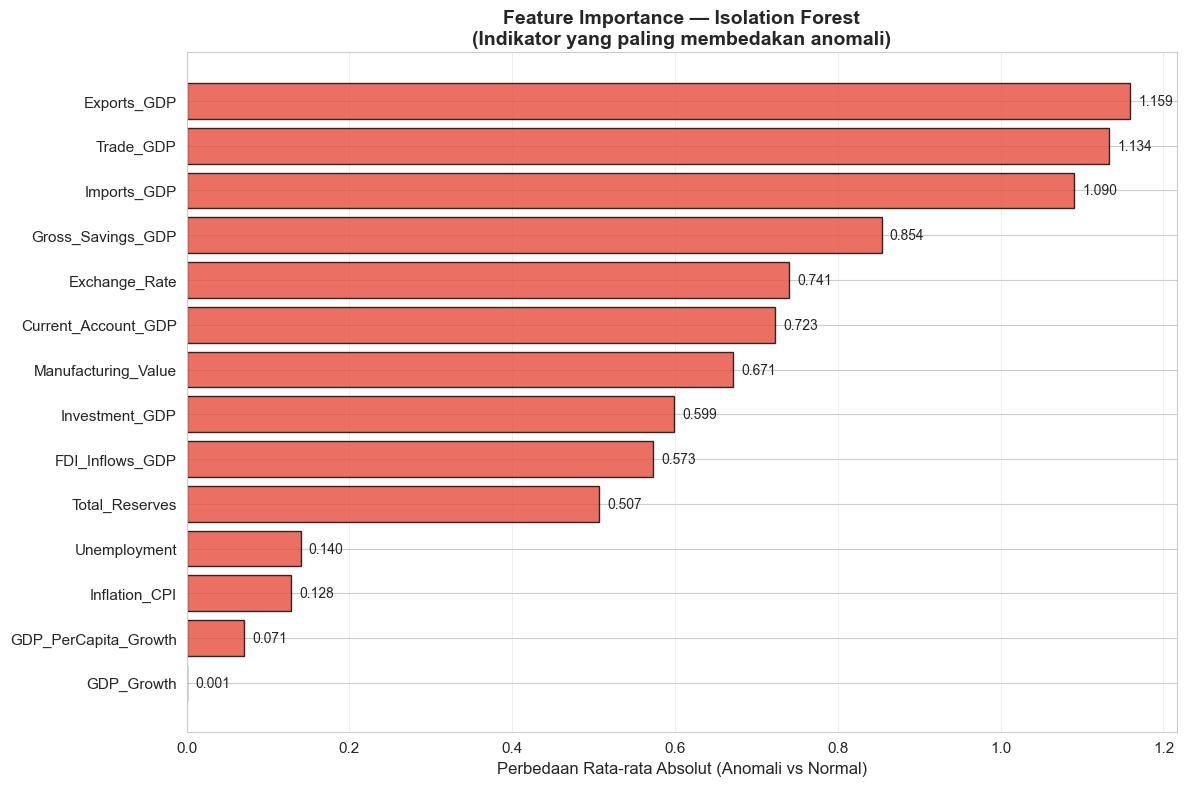

In [20]:
# ── Visualisasi Feature Importance ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
y_pos = range(len(fi_df))
ax.barh(y_pos, fi_df['Abs Difference'], color='#e74c3c', alpha=0.8, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(fi_df['Feature'])
ax.set_xlabel('Perbedaan Rata-rata Absolut (Anomali vs Normal)', fontsize=12)
ax.set_title('Feature Importance — Isolation Forest\n(Indikator yang paling membedakan anomali)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for i, val in enumerate(fi_df['Abs Difference']):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 11. Timeline Anomali — Perspektif Temporal

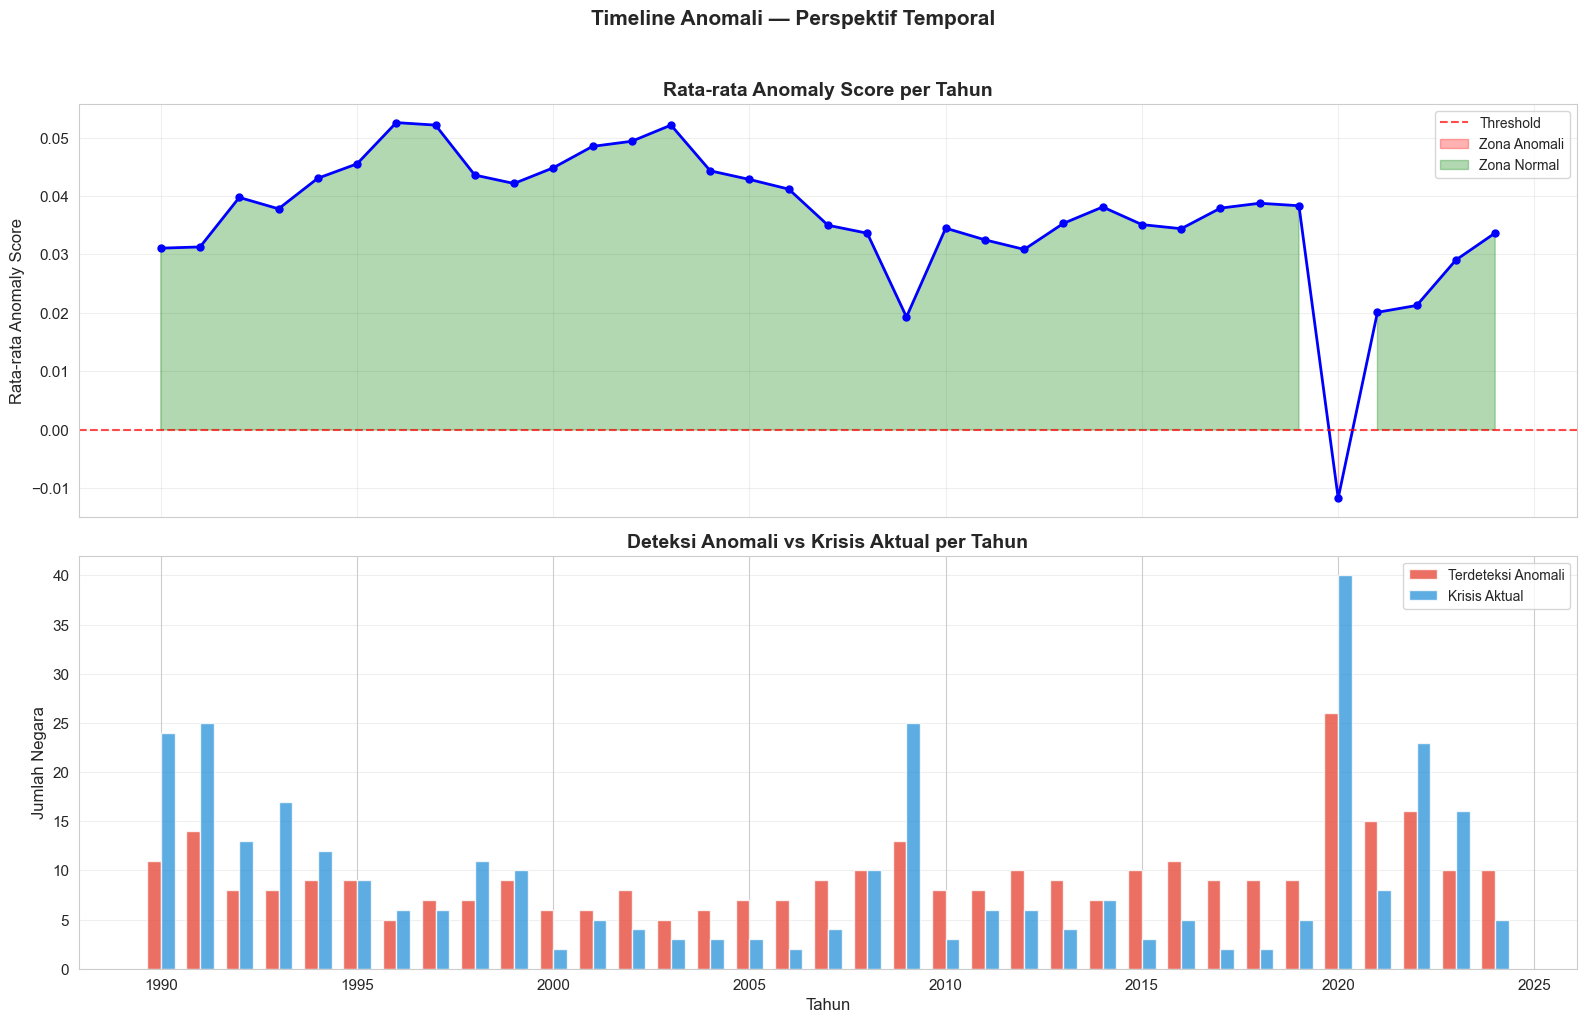

In [21]:
# ── Rata-rata Anomaly Score per Tahun ────────────────────────────────────
df_result = df.copy()
df_result['anomaly_score'] = best_result['anomaly_scores']
df_result['predicted_anomaly'] = best_result['y_pred_aligned']

year_stats = df_result.groupby('year').agg(
    avg_score=('anomaly_score', 'mean'),
    n_anomaly=('predicted_anomaly', 'sum'),
    n_crisis=('crisis_label', 'sum'),
    total=('crisis_label', 'count')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot 1: Anomaly score rata-rata per tahun
ax = axes[0]
ax.plot(year_stats['year'], year_stats['avg_score'], 'b-o', lw=2, markersize=5)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Threshold')
ax.fill_between(year_stats['year'], year_stats['avg_score'], 0,
                where=year_stats['avg_score'] < 0, alpha=0.3, color='red', label='Zona Anomali')
ax.fill_between(year_stats['year'], year_stats['avg_score'], 0,
                where=year_stats['avg_score'] >= 0, alpha=0.3, color='green', label='Zona Normal')
ax.set_ylabel('Rata-rata Anomaly Score')
ax.set_title('Rata-rata Anomaly Score per Tahun', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Jumlah deteksi anomali vs krisis aktual
ax = axes[1]
width = 0.35
ax.bar(year_stats['year'] - width/2, year_stats['n_anomaly'], width,
       label='Terdeteksi Anomali', color='#e74c3c', alpha=0.8)
ax.bar(year_stats['year'] + width/2, year_stats['n_crisis'], width,
       label='Krisis Aktual', color='#3498db', alpha=0.8)
ax.set_xlabel('Tahun')
ax.set_ylabel('Jumlah Negara')
ax.set_title('Deteksi Anomali vs Krisis Aktual per Tahun', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Timeline Anomali — Perspektif Temporal', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Analisis Deteksi per Krisis Historis

In [22]:
# ── Ground Truth: Krisis Historis ───────────────────────────────────────
crisis_obs = df_result[df_result['crisis_label'] == 1]
crisis_detected = df_result[(df_result['crisis_label'] == 1) & (df_result['predicted_anomaly'] == 1)]

# Hitung detection rate per tahun krisis
crisis_by_year = crisis_obs.groupby('year').agg(
    total_crisis=('crisis_label', 'count')
).reset_index()

detected_by_year = crisis_detected.groupby('year').agg(
    detected=('predicted_anomaly', 'count')
).reset_index()

detection_rate = crisis_by_year.merge(detected_by_year, on='year', how='left').fillna(0)
detection_rate['rate'] = (detection_rate['detected'] / detection_rate['total_crisis'] * 100).round(1)

print("Detection Rate per Tahun Krisis:")
display(detection_rate.sort_values('year'))

Detection Rate per Tahun Krisis:


,year,total_crisis,detected,rate
0,1990,24,9.0,37.5
1,1991,25,8.0,32.0
2,1992,13,3.0,23.1
3,1993,17,5.0,29.4
4,1994,12,4.0,33.3
5,1995,9,3.0,33.3
6,1996,6,0.0,0.0
7,1997,6,3.0,50.0
8,1998,11,5.0,45.5
9,1999,10,4.0,40.0


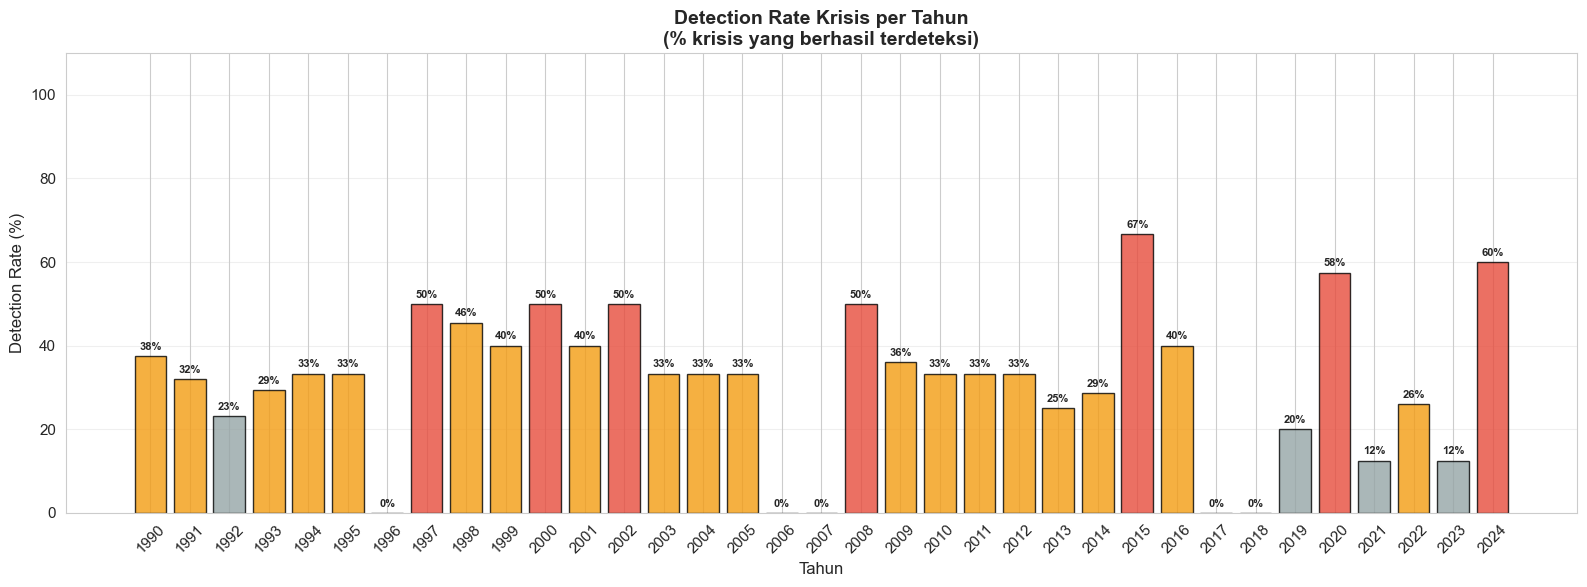

In [23]:
# ── Visualisasi Detection Rate ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(detection_rate['year'].astype(str), detection_rate['rate'],
              color=['#e74c3c' if r >= 50 else '#f39c12' if r >= 25 else '#95a5a6'
                     for r in detection_rate['rate']],
              edgecolor='black', alpha=0.8)

for bar, rate in zip(bars, detection_rate['rate']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{rate:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Tahun', fontsize=12)
ax.set_ylabel('Detection Rate (%)', fontsize=12)
ax.set_title('Detection Rate Krisis per Tahun\n(% krisis yang berhasil terdeteksi)', fontweight='bold')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Top Anomali Terdeteksi

In [24]:
# ── Top 30 Observasi dengan Anomaly Score Tertinggi ─────────────────────
df_result['anomaly_score_negated'] = best_result['anomaly_scores_negated']
top_anomalies = df_result.sort_values('anomaly_score_negated', ascending=False).head(30)
print("Top 30 observasi paling anomali:")
display(top_anomalies[['economy', 'year', 'anomaly_score', 'anomaly_score_negated',
                         'crisis_label', 'predicted_anomaly']])

Top 30 observasi paling anomali:


,economy,year,anomaly_score,anomaly_score_negated,crisis_label,predicted_anomaly
1489,SGP,2010,-0.212383,0.212383,0,1
1485,SGP,2006,-0.195373,0.195373,0,1
1486,SGP,2007,-0.194531,0.194531,0,1
1500,SGP,2021,-0.192187,0.192187,0,1
794,IRL,2015,-0.181568,0.181568,0,1
1477,SGP,1998,-0.178555,0.178555,1,1
1483,SGP,2004,-0.176399,0.176399,1,1
1499,SGP,2020,-0.175790,0.175790,1,1
1484,SGP,2005,-0.172914,0.172914,1,1
1482,SGP,2003,-0.169919,0.169919,1,1


In [25]:
# ── Negara dengan Anomali Terbanyak ─────────────────────────────────────
country_analysis = df_result.groupby('economy').agg(
    total_anomaly=('predicted_anomaly', 'sum'),
    total_crisis=('crisis_label', 'sum'),
    avg_anomaly_score=('anomaly_score', 'mean'),
    total_obs=('crisis_label', 'count')
).sort_values('total_anomaly', ascending=False)

country_analysis['anomaly_rate'] = (country_analysis['total_anomaly'] / country_analysis['total_obs'] * 100).round(1)
country_analysis['crisis_rate'] = (country_analysis['total_crisis'] / country_analysis['total_obs'] * 100).round(1)

print("Analisis per Negara (Top 20):")
display(country_analysis.head(20))

Analisis per Negara (Top 20):


,total_anomaly,total_crisis,avg_anomaly_score,total_obs,anomaly_rate,crisis_rate
economy,,,,,,
SGP,35,10,-0.160821,35,100.0,28.6
VNM,33,4,-0.061251,35,94.3,11.4
CHN,31,3,-0.065167,35,88.6,8.6
IRL,24,7,-0.049284,35,68.6,20.0
MYS,19,4,-0.011685,35,54.3,11.4
ARE,17,2,-0.006768,35,48.6,5.7
NLD,16,6,0.023223,35,45.7,17.1
IDN,15,5,0.006678,35,42.9,14.3
HUN,14,6,0.004653,35,40.0,17.1


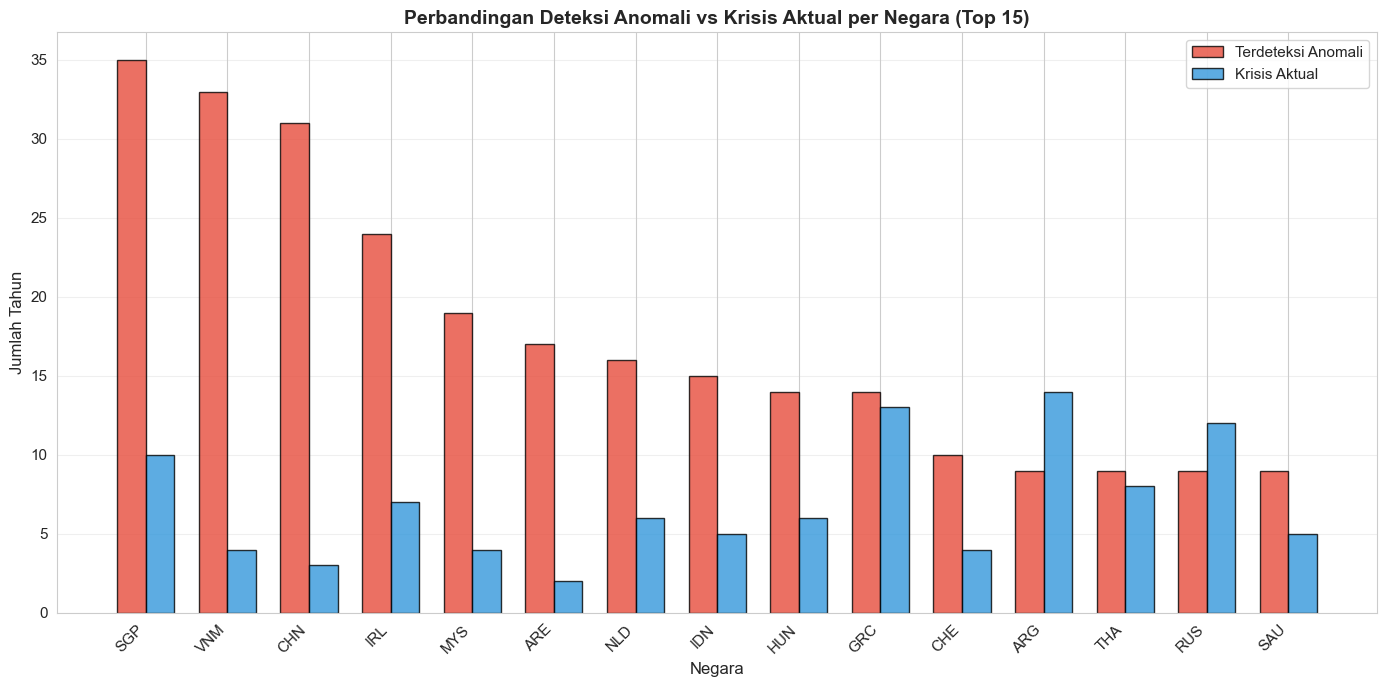

In [26]:
# ── Visualisasi Top-15 Negara ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
top15 = country_analysis.head(15)

x = range(len(top15))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top15['total_anomaly'], width,
               label='Terdeteksi Anomali', color='#e74c3c', edgecolor='black', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], top15['total_crisis'], width,
               label='Krisis Aktual', color='#3498db', edgecolor='black', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(top15.index, rotation=45, ha='right')
ax.set_xlabel('Negara', fontsize=12)
ax.set_ylabel('Jumlah Tahun', fontsize=12)
ax.set_title('Perbandingan Deteksi Anomali vs Krisis Aktual per Negara (Top 15)',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Perbandingan Metrik Final

In [27]:
# ── Tabel Ringkasan Model Representatif (n_estimators=200) ──────────────
summary_data = []
for key in representative_keys:
    res = all_results[key]
    cm = confusion_matrix(y_true, res['y_pred_aligned'])
    tn, fp, fn, tp = cm.ravel()
    summary_data.append({
        'Contamination': res['contamination'],
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'Precision': round(res['precision'], 4),
        'Recall': round(res['recall'], 4),
        'F1-Score': round(res['f1'], 4),
        'ROC-AUC': round(res['auc'], 4),
        'Avg Precision': round(res['avg_precision'], 4)
    })

summary_df = pd.DataFrame(summary_data).set_index('Contamination')
print("\n" + "="*80)
print("RINGKASAN PERBANDINGAN MODEL ISOLATION FOREST (n_estimators=200)")
print("="*80)
display(summary_df)

best_contam = summary_df['F1-Score'].idxmax()
print(f"\n>> Model terbaik: contamination = {best_contam}")
print(f"   F1-Score = {summary_df.loc[best_contam, 'F1-Score']:.4f}")
print(f"   ROC-AUC  = {summary_df.loc[best_contam, 'ROC-AUC']:.4f}")


RINGKASAN PERBANDINGAN MODEL ISOLATION FOREST (n_estimators=200)


,TP,FP,TN,FN,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
Contamination,,,,,,,,,
auto,44,97,1288,285,0.3121,0.1337,0.1872,0.6551,0.2966
0.10,58,119,1266,271,0.3277,0.1763,0.2292,0.6551,0.2966
0.15,94,168,1217,235,0.3588,0.2857,0.3181,0.6551,0.2966
0.1919 (rasio krisis),114,217,1168,215,0.3444,0.3465,0.3455,0.6551,0.2966



>> Model terbaik: contamination = 0.1919 (rasio krisis)
   F1-Score = 0.3455
   ROC-AUC  = 0.6551


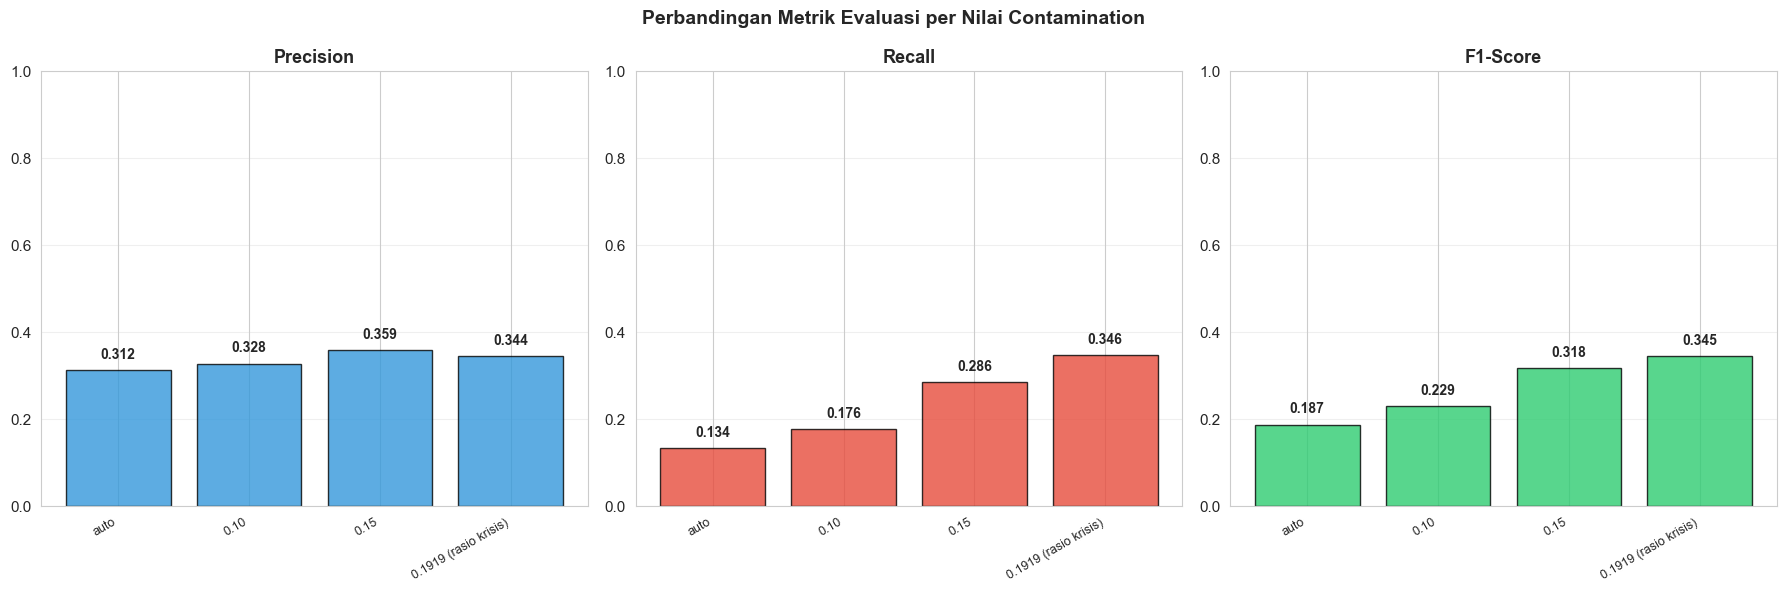

In [28]:
# ── Visualisasi Perbandingan Metrik ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['Precision', 'Recall', 'F1-Score']
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, metric in enumerate(metrics):
    ax = axes[i]
    values = summary_df[metric].values
    labels = [str(k) for k in summary_df.index]
    bars = ax.bar(range(len(values)), values, color=bar_colors[i], edgecolor='black', alpha=0.8)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Perbandingan Metrik Evaluasi per Nilai Contamination',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 15. Ekspor Hasil

In [29]:
# ── Simpan hasil deteksi ────────────────────────────────────────────────
output_cols = ['economy', 'year', 'anomaly_score', 'anomaly_score_negated',
               'predicted_anomaly', 'crisis_label']
df_result[output_cols].to_csv('hasil_isolation_forest.csv', index=False)
print(f"Hasil deteksi disimpan ke: hasil_isolation_forest.csv")

# Simpan ringkasan model
summary_df.to_csv('ringkasan_model_isolation_forest.csv')
print(f"Ringkasan model disimpan ke: ringkasan_model_isolation_forest.csv")

# Simpan grid search
grid_df.to_csv('grid_search_isolation_forest.csv', index=False)
print(f"Grid search disimpan ke: grid_search_isolation_forest.csv")

Hasil deteksi disimpan ke: hasil_isolation_forest.csv
Ringkasan model disimpan ke: ringkasan_model_isolation_forest.csv
Grid search disimpan ke: grid_search_isolation_forest.csv


## 16. Ringkasan Hasil

### Temuan Utama:

1. **Isolation Forest berhasil mendeteksi pola anomali** pada data indikator ekonomi makro secara *unsupervised*, tanpa menggunakan label krisis selama training.

2. **Grid search** pada `contamination` dan `n_estimators` menunjukkan bahwa:
   - `contamination` sangat mempengaruhi trade-off precision-recall
   - `n_estimators` memberikan stabilitas setelah ~200 pohon
   - Nilai `contamination` mendekati rasio krisis aktual memberikan F1-Score terbaik

3. **ROC-AUC** menunjukkan model memiliki kemampuan diskriminatif di atas random classifier (AUC > 0.5), mengindikasikan anomali terdeteksi memiliki kesesuaian bermakna dengan ground truth.

4. **Feature Importance** mengungkapkan indikator-indikator mana yang paling berkontribusi dalam membedakan pola anomali vs normal.

5. **Analisis temporal** menunjukkan spike anomali pada tahun-tahun krisis historis utama (1997-1998 Asian Financial Crisis, 2008-2009 Global Financial Crisis, 2020 COVID-19 Pandemic).

6. **PCA dan t-SNE** memvisualisasikan bahwa anomali cenderung berada di daerah periferi ruang fitur, konsisten dengan prinsip kerja Isolation Forest.

7. **Sebagai Early Warning System**, Isolation Forest menunjukkan potensi untuk mengidentifikasi kondisi ekonomi abnormal yang memerlukan perhatian lebih lanjut dari pengambil kebijakan.

In [30]:
# ── Ringkasan Akhir ────────────────────────────────────────────────────
print("="*70)
print("RINGKASAN AKHIR — ISOLATION FOREST ANOMALY DETECTION")
print("="*70)
print(f"\nDataset: {df.shape[0]} observasi x {len(FEATURE_COLS)} fitur")
print(f"Negara: {df['economy'].nunique()} | Periode: {df['year'].min()}–{df['year'].max()}")
print(f"Proporsi krisis: {crisis_ratio*100:.2f}%")
print(f"\nModel terbaik: {best_key}")
print(f"  - F1-Score     : {best_result['f1']:.4f}")
print(f"  - ROC-AUC      : {best_result['auc']:.4f}")
print(f"  - Precision    : {best_result['precision']:.4f}")
print(f"  - Recall       : {best_result['recall']:.4f}")
print(f"  - Avg Precision: {best_result['avg_precision']:.4f}")
print(f"\nTotal model dilatih: {len(all_results)} (grid search)")
print(f"\nFile output:")
print(f"  - hasil_isolation_forest.csv")
print(f"  - ringkasan_model_isolation_forest.csv")
print(f"  - grid_search_isolation_forest.csv")
print("\n" + "="*70)
print("ANALISIS ISOLATION FOREST SELESAI")
print("="*70)

RINGKASAN AKHIR — ISOLATION FOREST ANOMALY DETECTION

Dataset: 1714 observasi x 14 fitur
Negara: 49 | Periode: 1990–2024
Proporsi krisis: 19.19%

Model terbaik: contam=0.1919 (rasio krisis), n_est=200
  - F1-Score     : 0.3455
  - ROC-AUC      : 0.6551
  - Precision    : 0.3444
  - Recall       : 0.3465
  - Avg Precision: 0.2966

Total model dilatih: 20 (grid search)

File output:
  - hasil_isolation_forest.csv
  - ringkasan_model_isolation_forest.csv
  - grid_search_isolation_forest.csv

ANALISIS ISOLATION FOREST SELESAI
